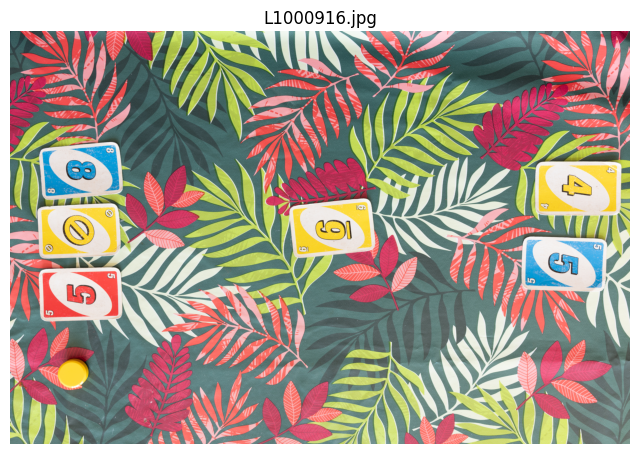

In [110]:
from importlib import reload
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_v2.card_detection_helpers as helpers
reload(helpers)
from segmentation_v2.card_detection_helpers import *

BASE_DIR = Path.cwd()
TRAIN_DIR = BASE_DIR / "iapr-26-uno-vision-challenge" / "train_images"

image_path = TRAIN_DIR / "L1000916.jpg" #L1000838 or L1000983
#image_path = BASE_DIR / "iapr-26-uno-vision-challenge" / "reference_images" / "L1000765.jpg"
img_color = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(img_color)
plt.title(image_path.name)
plt.axis("off")
plt.show()


In [111]:
"""# Apply histogram equalization to the original image
img_array = np.array(img_color)
img_yuv = cv2.cvtColor(img_array, cv2.COLOR_RGB2YCrCb)

# Equalize only the Y channel (luminance)
img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])

# Convert back to RGB
img_equalized = cv2.cvtColor(img_yuv, cv2.COLOR_YCrCb2RGB)

# Display comparison
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_color)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_equalized)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()"""

'# Apply histogram equalization to the original image\nimg_array = np.array(img_color)\nimg_yuv = cv2.cvtColor(img_array, cv2.COLOR_RGB2YCrCb)\n\n# Equalize only the Y channel (luminance)\nimg_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])\n\n# Convert back to RGB\nimg_equalized = cv2.cvtColor(img_yuv, cv2.COLOR_YCrCb2RGB)\n\n# Display comparison\nplt.figure(figsize=(16, 6))\n\nplt.subplot(1, 2, 1)\nplt.imshow(img_color)\nplt.title("Original Image")\nplt.axis("off")\n\nplt.subplot(1, 2, 2)\nplt.imshow(img_equalized)\nplt.title("Histogram Equalized Image")\nplt.axis("off")\n\nplt.tight_layout()\nplt.show()'

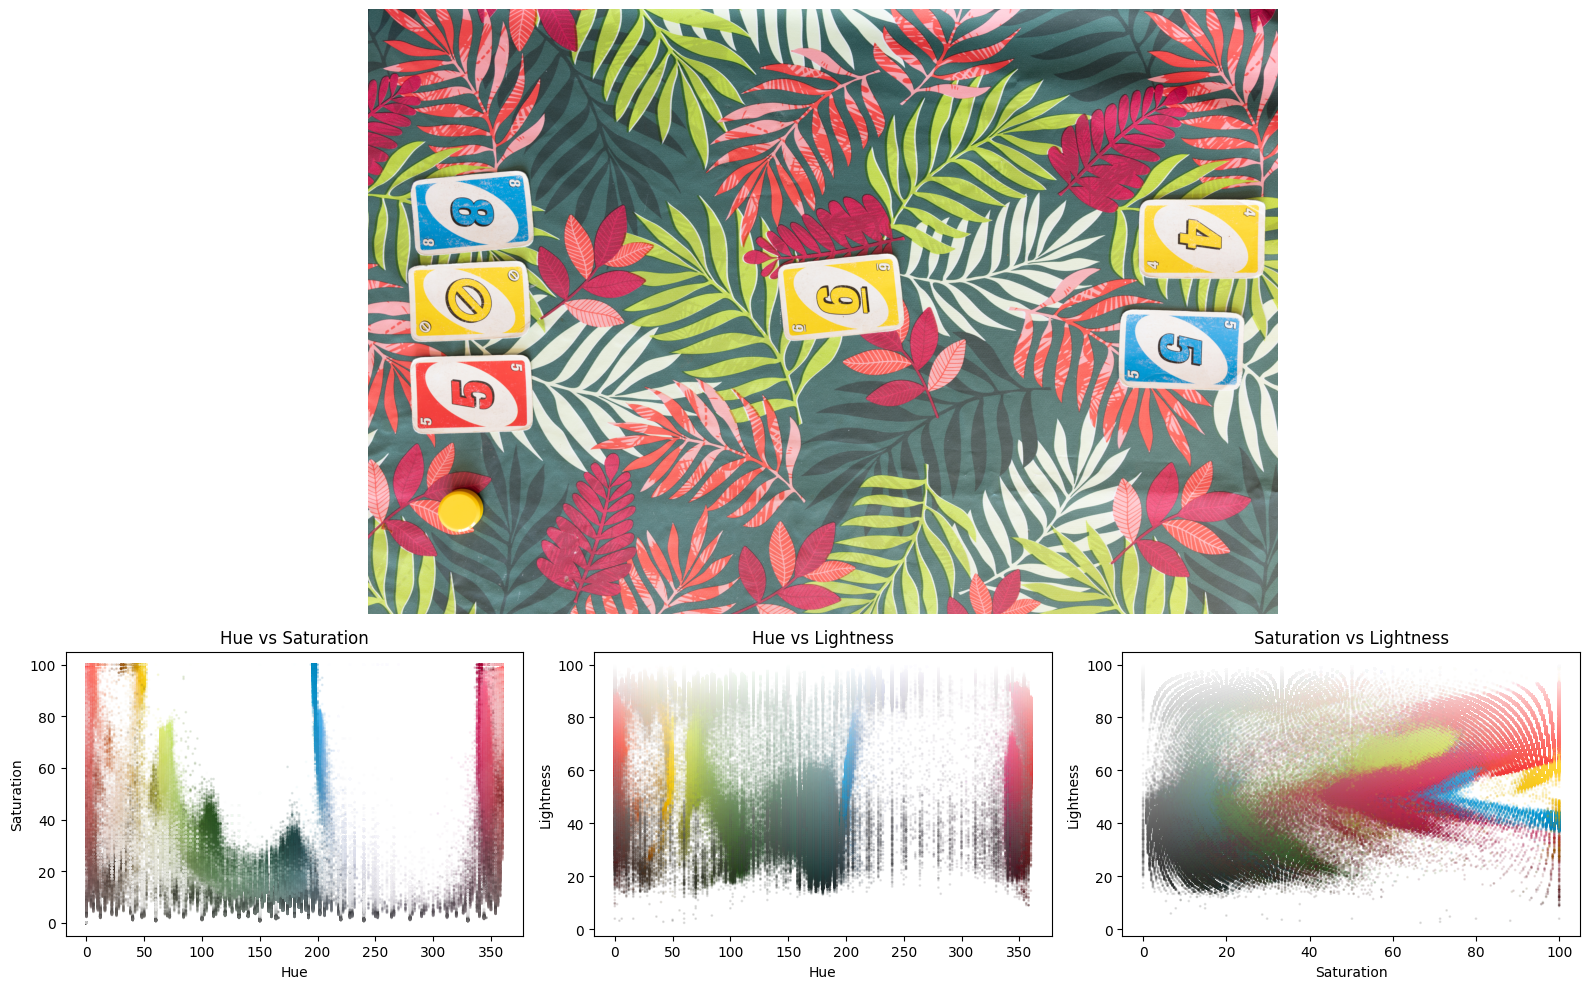

In [112]:
helpers.plot_colors_histo(
    img=np.array(img_color),
    func=extract_hsl_channels,
    labels=["Hue", "Saturation", "Lightness"],
)


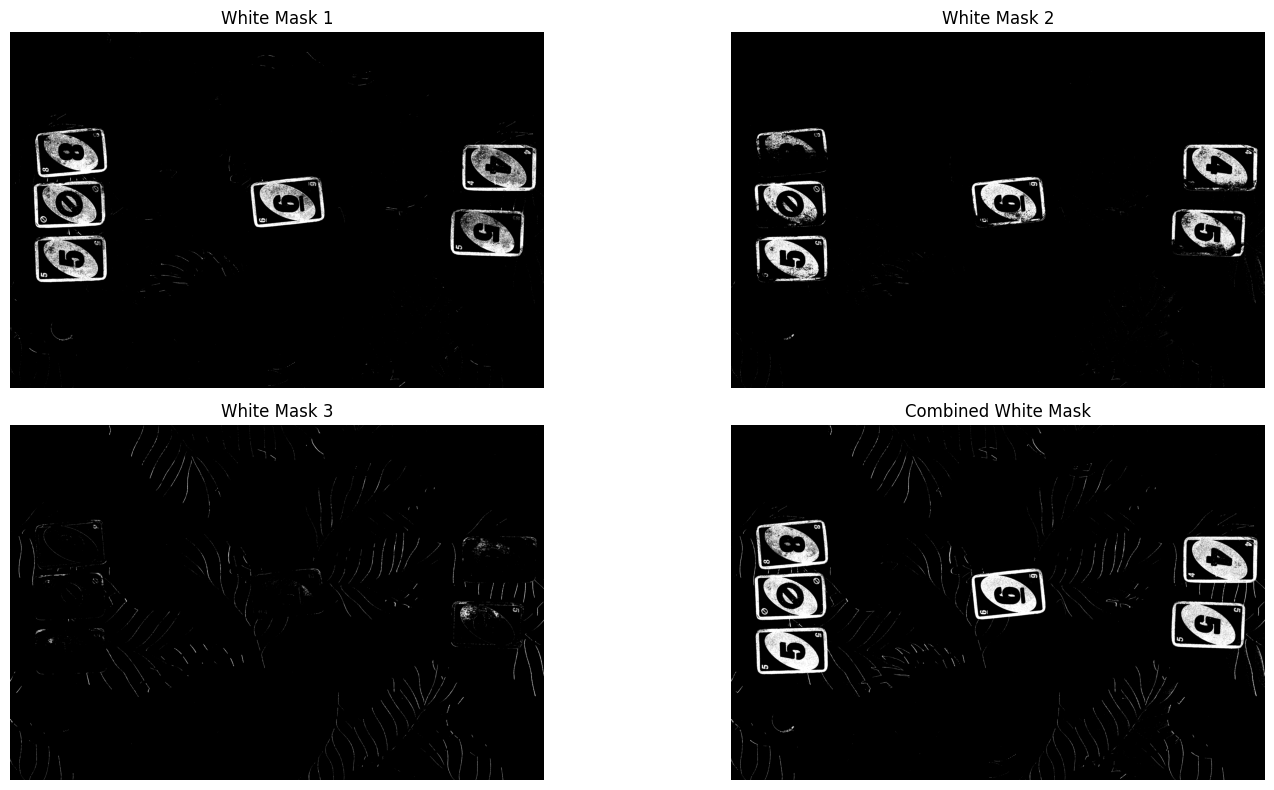

In [122]:
lower_white_1 = np.array([15.0, 0.0, 60.0])
upper_white_1 = np.array([40.0, 100.0, 100.0])

lower_white_2 = np.array([10, 0.0, 90.0])
upper_white_2 = np.array([50, 100.0, 100.0])

lower_white_3 = np.array([230, 0.0, 80.0])
upper_white_3 = np.array([330, 100.0, 100.0])

white_mask_1, white_mask_2, white_mask_3, white_mask = helpers.mask(lower_white_1, upper_white_1, lower_white_2, upper_white_2, lower_white_3, upper_white_3, img_color)

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(white_mask_1, cmap="gray")
plt.title("White Mask 1")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(white_mask_2, cmap="gray")
plt.title("White Mask 2")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(white_mask_3, cmap="gray")
plt.title("White Mask 3")
plt.axis("off")


plt.subplot(2, 2, 4)
plt.imshow(white_mask, cmap="gray")
plt.title("Combined White Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


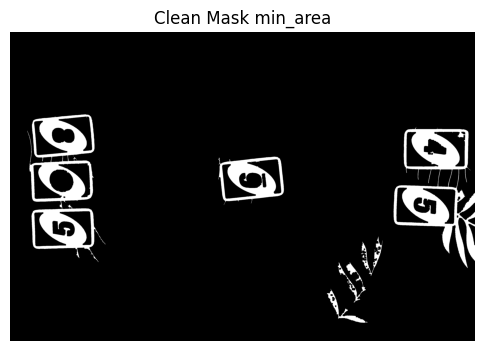

In [114]:
# Remove small connected areas from the combined white mask
white_mask_u8 = white_mask.astype(np.uint8) * 255
closed_frame = helpers.close(3,5, white_mask_u8)
clean_mask = helpers.min_area_filter(closed_frame, min_area=10000)
plt.figure(figsize=(6, 5))

plt.imshow(clean_mask, cmap="gray")
plt.title(f"Clean Mask min_area")
plt.axis("off")

plt.show()


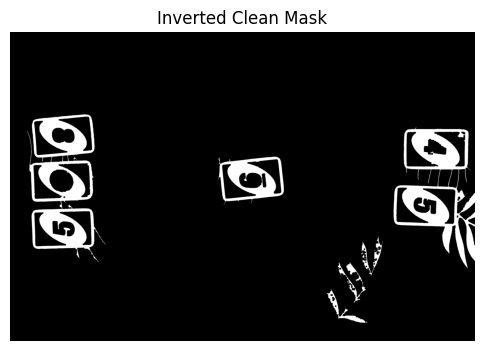

In [115]:
WHITE = None
if clean_mask.mean() >= 0.5:
    WHITE = True
    #clean_mask = (1-clean_mask).astype(np.uint8)
else :
    WHITE = False
    clean_mask = (clean_mask).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(clean_mask, cmap="gray")
plt.title("Inverted Clean Mask")
plt.axis("off")
plt.show()


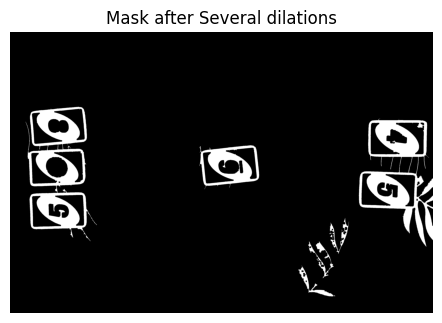

In [116]:
import cv2

morph_mask = clean_mask.copy()
if WHITE:
    #kernel = np.ones((5, 5), np.uint8)
    #morph_mask = cv2.morphologyEx(morph_mask, cv2.MORPH_ERODE, kernel,iterations=5)
    ...
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(morph_mask, cmap="gray")
plt.title("Mask after Several dilations")
plt.axis("off")
plt.show()


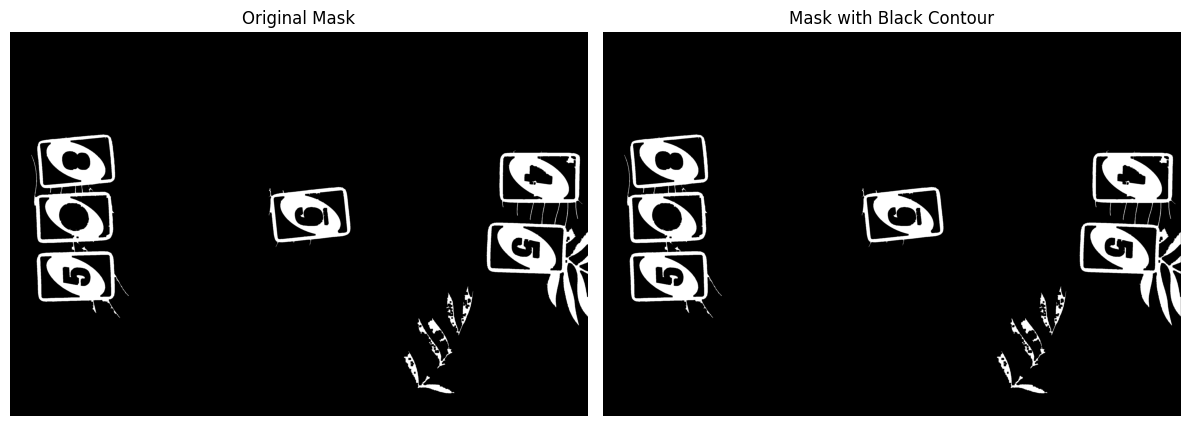

In [117]:
# Add a one pixel black contour around the frame
framed_morph_mask = helpers.black_contours(morph_mask)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(morph_mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(framed_morph_mask, cmap="gray")
plt.title("Mask with Black Contour")
plt.axis("off")

plt.tight_layout()
plt.show()

morph_mask = framed_morph_mask

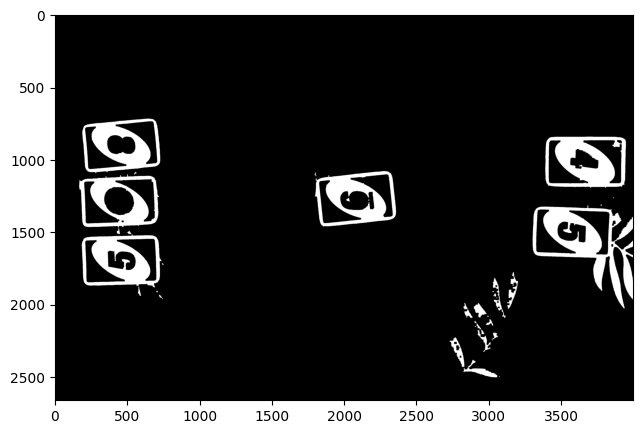

In [118]:
morph_mask=helpers.open(5,1, framed_morph_mask)
plt.figure(figsize=(12, 5))
plt.imshow(morph_mask, cmap="gray")

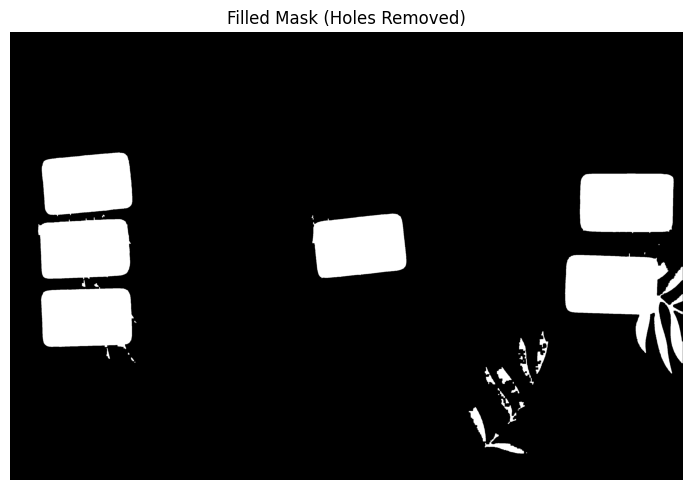

In [119]:
filled_mask = helpers.fill_cards(morph_mask)
edges = cv2.Canny(filled_mask * 255, 0, 0)

plt.figure(figsize=(12, 5))

plt.imshow(filled_mask, cmap="gray")
plt.title("Filled Mask (Holes Removed)")
plt.axis("off")

plt.tight_layout()
plt.show()



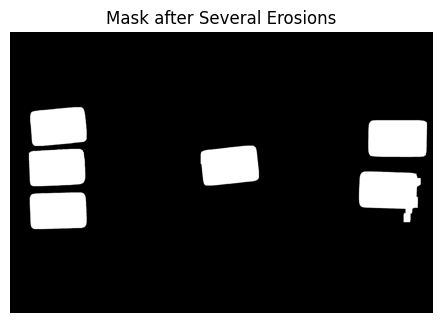

In [120]:
import cv2

eroded_mask_filled = filled_mask.copy()
if not WHITE:
    kernel = np.ones((5, 5), np.uint8)
    eroded_mask_filled = cv2.morphologyEx(eroded_mask_filled, cv2.MORPH_OPEN, kernel,iterations=15)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(eroded_mask_filled, cmap="gray")
plt.title("Mask after Several Erosions")
plt.axis("off")
plt.show()


NameError: name 'min_area_filed' is not defined

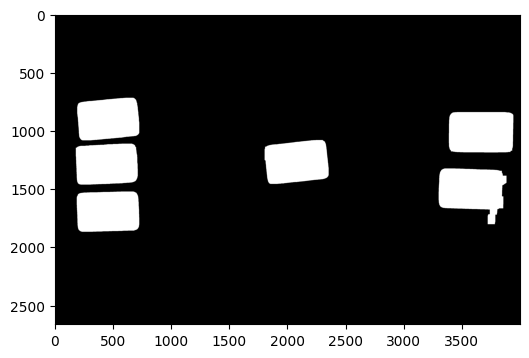

In [121]:
# Perform area filtering on the filled mask to remove small connected components
filtered_mask = eroded_mask_filled.copy()

'''num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(eroded_mask_filled.astype(np.uint8), connectivity=8)
if not WHITE:
    min_area_filed = 100000
    filtered_mask = np.zeros_like(eroded_mask_filled, dtype=np.uint8)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area_filed:
            filtered_mask[labels == label] = 1'''
        
# Plot the filtered mask
plt.figure(figsize=(6, 6))
plt.imshow(filtered_mask, cmap="gray")
plt.title("Filtered Mask (min_area={})".format(min_area_filed))
plt.axis("off")
plt.show()

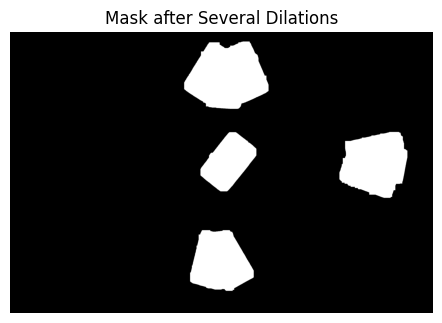

In [ ]:
dilated_mask_filled = filtered_mask.copy()
'''if not WHITE:
    kernel = np.ones((5, 5), np.uint8)
    dilated_mask_filled = cv2.morphologyEx(dilated_mask_filled, cv2.MORPH_DILATE, kernel,iterations=10)
else:
    kernel = np.ones((5, 5), np.uint8)
    dilated_mask_filled = cv2.morphologyEx(dilated_mask_filled, cv2.MORPH_DILATE, kernel,iterations=3)
'''

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(dilated_mask_filled, cmap="gray")
plt.title("Mask after Several Dilations")
plt.axis("off")
plt.show()

In [ ]:
# Apply Canny edge detection on the cleaned white mask
edges = cv2.Canny((dilated_mask_filled.astype(np.uint8) * 255), 0, 0)

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.imshow(dilated_mask_filled, cmap="gray")
plt.title("Clean Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()


NameError: name 'dilated_mask_filled' is not defined

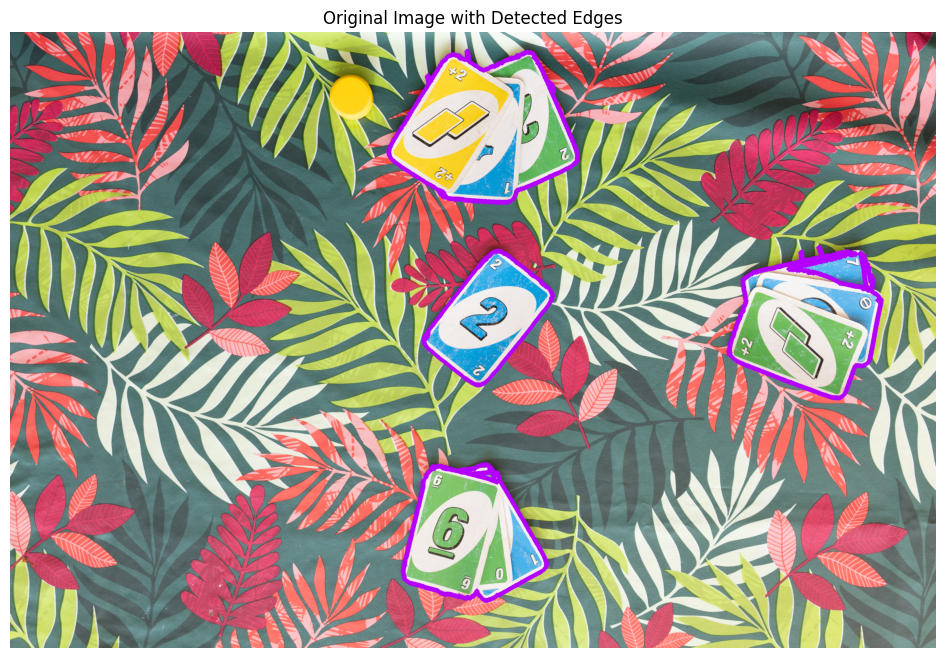

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
thick_edges = cv2.dilate(edges, kernel, iterations=10)

img_with_edges = np.array(img_color).copy()
img_with_edges[thick_edges > 0] = [180, 0, 255]  # Overlay edges in red

plt.figure(figsize=(12, 8))
plt.imshow(img_with_edges)
plt.title("Original Image with Detected Edges")
plt.axis("off")
plt.show()